In [14]:
from urllib.robotparser import RobotFileParser
import requests

url = "https://www.gog.com/ru/"
ua = "MyBot"

rp = RobotFileParser("https://www.gog.com/robots.txt")
rp.read()

if rp.can_fetch(ua, url):
    print("Allowed")
    print(requests.get(url, headers={"User-Agent": ua}).text[:200])
else:
    print("Blocked by robots.txt")

Allowed
<!DOCTYPE html><html lang="ru" dir="ltr"><!-- version: 97b6f128 --><head>
        <meta charset="utf-8">
        <title>Добро пожаловать на GOG.com | лучшие компьютерные игры без DRM</title>
        <


In [ ]:
#python gog_scraper.py
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed

CATALOG_URL = "https://www.gog.com/games/ajax/filtered"

TARGET = 5000
PAGES = 300
MAX_WORKERS = 20

HEADERS = {"User-Agent": "Mozilla/5.0 StudentResearchScraper/1.0"}

logging.basicConfig(
    filename="gog_scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

session = requests.Session()
session.headers.update(HEADERS)


def safe_get(url, params=None, retries=3, timeout=12):
    for attempt in range(retries):
        try:
            r = session.get(url, params=params, timeout=timeout)
            if r.status_code == 200:
                return r
        except Exception as e:
            logging.error(f"Request error: {url} | {e}")

        time.sleep(0.5 + attempt)

    return None


def clean(x):
    return " ".join(str(x).split()) if x else "N/A"


def get_genre(genres):
    if isinstance(genres, list):
        return ", ".join([
            g.get("name", "") if isinstance(g, dict) else str(g)
            for g in genres
        ])
    return "N/A"


def get_price(price_data):
    if isinstance(price_data, dict):
        for key in ["finalAmount", "amount", "baseAmount"]:
            value = price_data.get(key)
            if value not in [None, "", "None"]:
                m = re.search(r"\d+(?:[.,]\d{1,2})?", str(value))
                if m:
                    return m.group(0).replace(",", ".")
    return "N/A"


def get_discount(price_data):
    if not isinstance(price_data, dict):
        return "0"

    try:
        base = float(str(price_data.get("baseAmount")).replace(",", "."))
        final = float(str(price_data.get("finalAmount") or price_data.get("amount")).replace(",", "."))

        if base > final and base > 0:
            return str(round((1 - final / base) * 100))
    except:
        pass

    return "0"


def get_rating(text, api_rating):
    m = re.search(r"(\d+(?:\.\d+)?)\s*/\s*5", text)
    return m.group(1) if m else api_rating


def get_votes(text):
    m = re.search(r"\(([\d,\s]+)\s*(Reviews?|отзыв)", text, re.I)
    if m:
        return m.group(1).replace(",", "").replace(" ", "")
    return "N/A"


def get_date(text, api_date):
    months = {
        "января": "01", "февраля": "02", "марта": "03",
        "апреля": "04", "мая": "05", "июня": "06",
        "июля": "07", "августа": "08", "сентября": "09",
        "октября": "10", "ноября": "11", "декабря": "12"
    }

    m = re.search(r"Дата выхода:\s*(\d{1,2})\s+([а-яё]+)\s+(\d{4})", text, re.I)

    if m:
        return f"{m.group(3)}-{months.get(m.group(2).lower(), '01')}-{m.group(1).zfill(2)}"

    try:
        if str(api_date).isdigit():
            return pd.to_datetime(int(api_date), unit="s").strftime("%Y-%m-%d")
    except:
        pass

    return "N/A"


def get_author(text):
    m = re.search(r"Компания:\s*([A-Za-zА-Яа-я0-9 .,&'’\-\/]+)", text)

    if m:
        author = clean(m.group(1))
        for stop in ["Ссылки", "Обсуждение", "Особенности", "Языки", "Отзывы", "GOOD OLD GAME"]:
            author = author.split(stop)[0].strip()
        return author[:100]

    return "Unknown"


def get_platform(text):
    platforms = []
    if "Windows" in text:
        platforms.append("Windows")
    if "Mac" in text:
        platforms.append("Mac")
    if "Linux" in text:
        platforms.append("Linux")

    return ", ".join(platforms) if platforms else "N/A"



# STEP 1: COLLECT PRODUCTS FAST


products = []

for page in range(1, PAGES + 1):
    if len(products) >= TARGET:
        break

    params = {
        "mediaType": "game",
        "page": page,
        "sort": "popularity",
        "countryCode": "US",
        "currencyCode": "USD"
    }

    print(f"Collecting page {page} | total: {len(products)}")

    r = safe_get(CATALOG_URL, params=params)

    if not r:
        continue

    try:
        js = r.json()
        page_products = js.get("products", [])
        products.extend(page_products)
    except Exception as e:
        logging.error(f"JSON error: {e}")

    time.sleep(0.05)

products = products[:TARGET]
print("Total products:", len(products))



# STEP 2: SCRAPE DETAILS IN PARALLEL


def scrape_game(game):
    try:
        app_id = game.get("id", "N/A")
        slug = game.get("slug", "")
        title = clean(game.get("title", "N/A"))
        product_url = "https://www.gog.com/ru/game/" + slug

        price = get_price(game.get("price", {}))
        discount = get_discount(game.get("price", {}))
        genre = get_genre(game.get("genres", []))
        rating = game.get("rating", "N/A")
        released_date = get_date("", game.get("releaseDate", "N/A"))

        votes = "N/A"
        platform = "N/A"
        director_author = "Unknown"
        runtime_pages = 0

        r = safe_get(product_url, retries=2, timeout=8)

        if r:
            soup = BeautifulSoup(r.text, "lxml")
            text = soup.get_text(" ", strip=True)

            h1 = soup.find("h1")
            if h1:
                title = clean(h1.get_text())

            rating = get_rating(text, rating)
            votes = get_votes(text)
            released_date = get_date(text, game.get("releaseDate", "N/A"))
            platform = get_platform(text)
            director_author = get_author(text)
            runtime_pages = len(text)

            soup.find_all("a", href=True)

        return {
            "APP_ID": app_id,
            "Title": title,
            "Genre": genre,
            "Rating": rating,
            "Votes_In_Rates": votes,
            "Released_Date": released_date,
            "Discount": discount,
            "Price": price,
            "Platform": platform,
            "Director_Author": director_author,
            "Product_URL": product_url,
            "Source": "GOG",
            "Runtime_Pages": runtime_pages
        }

    except Exception as e:
        logging.error(f"Game error: {e}")
        return None


data = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(scrape_game, game) for game in products]

    for i, future in enumerate(as_completed(futures), start=1):
        row = future.result()

        if row:
            data.append(row)

        if i % 250 == 0:
            print(f"Processed {i}/{len(products)} | saved {len(data)}")


df = pd.DataFrame(data)

df.to_csv("gog_raw_5000.csv", index=False, encoding="utf-8-sig")
df.to_json("gog_raw_5000.json", orient="records", indent=2, force_ascii=False)

print("DONE")
print("Rows:", len(df))
print(df.head())

Total products: 5000


Processed 250/5000 | saved 250


Processed 500/5000 | saved 500


Processed 750/5000 | saved 750


Processed 1000/5000 | saved 1000


...

ERROR:root:Request error: https://www.gog.com/ru/game/gwent_the_witcher_card_game | HTTPSConnectionPool(host='www.gog.com', port=443): Read timed out. (read timeout=8)


Processed 4250/5000 | saved 4250


Processed 4500/5000 | saved 4500


Processed 4750/5000 | saved 4750


Processed 5000/5000 | saved 5000
DONE
Rows: 5000
       APP_ID                                              Title  \
0  1841631965      Offworld Trading Company - Market Corrections   
1  2071181157                                        1000xRESIST   
2  1750687415  1428: Shadows over Silesia - Tourney at the Be...   
3  1280902753          The Excavation of Hob's Barrow - Art Book   
4  2050180334              1428: Shadows over Silesia Soundtrack   

                                Genre Rating Votes_In_Rates Released_Date  \
0        Simulation, Sci-fi, Strategy      0            N/A    2019-02-27   
1        Adventure, Puzzle, Narrative    4.3             49    2024-05-08   
2          Action, Adventure, Fantasy    4.8              1    2024-11-10   
3  Adventure, Point-and-click, Puzzle      0            N/A    2022-09-27   
4          Action, Adventure, Fantasy      0            N/A    2022-10-03   

  Discount  Price             Platform  \
0        0   3.99         Windows, Ma

In [ ]:
#python gog_cleaning.py
import pandas as pd
import numpy as np
import re

RAW_FILE = "gog_raw_5000.csv"

df_raw = pd.read_csv(RAW_FILE, encoding="utf-8-sig")
df = df_raw.copy()

print("Before cleaning:", df_raw.shape)
print(df_raw.head())



# 1. STANDARDIZE COLUMN NAMES


df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
)



# 2. REMOVE DUPLICATES


before_rows = len(df)

df = df.drop_duplicates(subset=["Product_URL"], keep="first")

duplicates_removed = before_rows - len(df)



# 3. TEXT NORMALIZATION


text_columns = [
    "Title",
    "Genre",
    "Platform",
    "Director_Author",
    "Product_URL",
    "Source"
]

for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .replace(["nan", "None", "N/A", ""], np.nan)
    )

df["Title"] = df["Title"].str.title()
df["Genre"] = df["Genre"].fillna("Unknown")
df["Platform"] = df["Platform"].fillna("Unknown")
df["Director_Author"] = df["Director_Author"].fillna("Unknown")
df["Source"] = df["Source"].fillna("GOG").str.upper()



# 4. CLEAN PRICE


def clean_price(x):
    if pd.isna(x):
        return np.nan

    x = str(x).replace("$", "").replace("USD", "").strip()

    if x.lower() in ["free", "бесплатно"]:
        return 0.0

    match = re.search(r"\d+(\.\d+)?", x)

    if match:
        return float(match.group())

    return np.nan


df["Price"] = df["Price"].apply(clean_price)



# 5. CLEAN DISCOUNT


def clean_discount(x):
    if pd.isna(x):
        return 0.0

    x = str(x).replace("%", "").replace("-", "").strip()

    try:
        return float(x)
    except:
        return 0.0


df["Discount"] = df["Discount"].apply(clean_discount)



# 6. CLEAN RATING


def clean_rating(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r"\d+(\.\d+)?", str(x))

    if match:
        return float(match.group())

    return np.nan


df["Rating"] = df["Rating"].apply(clean_rating)



# 7. CLEAN VOTES


def clean_votes(x):
    if pd.isna(x):
        return np.nan

    x = str(x).replace(",", "").replace(" ", "")

    match = re.search(r"\d+", x)

    if match:
        return int(match.group())

    return np.nan


df["Votes_In_Rates"] = df["Votes_In_Rates"].apply(clean_votes)


# 8. CLEAN RELEASE DATE


df["Released_Date"] = pd.to_datetime(df["Released_Date"], errors="coerce")



# 9. CLEAN RUNTIME / PAGE LENGTH


df["Runtime_Pages"] = pd.to_numeric(df["Runtime_Pages"], errors="coerce")



# 10. HANDLE MISSING VALUES


# numeric columns: flag then impute with median
numeric_columns = ["Price", "Rating", "Votes_In_Rates", "Runtime_Pages"]

for col in numeric_columns:
    df[col + "_Missing_Flag"] = df[col].isna()

    median_value = df[col].median()

    if pd.isna(median_value):
        median_value = 0

    df[col] = df[col].fillna(median_value)

# date: keep missing flag, do not fake exact dates
df["Released_Date_Missing_Flag"] = df["Released_Date"].isna()

# categorical columns: fill unknown
categorical_columns = ["Genre", "Platform", "Director_Author", "Source"]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

df["Title"] = df["Title"].fillna("Unknown Title")



# 11. OUTLIER DETECTION WITH IQR


def iqr_outlier(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (series < lower) | (series > upper), lower, upper


df["Price_Outlier"], price_low, price_high = iqr_outlier(df["Price"])
df["Rating_Outlier"], rating_low, rating_high = iqr_outlier(df["Rating"])
df["Votes_Outlier"], votes_low, votes_high = iqr_outlier(df["Votes_In_Rates"])



# 12. FEATURE ENGINEERING


today = pd.Timestamp.today()

df["Release_Year"] = df["Released_Date"].dt.year

df["Game_Age"] = today.year - df["Release_Year"]

df["Is_Discounted"] = df["Discount"] > 0

df["Price_To_Rating_Ratio"] = df["Price"] / (df["Rating"] + 0.01)

df["Platform_Count"] = df["Platform"].apply(
    lambda x: sum(platform.lower() in str(x).lower() for platform in ["windows", "mac", "linux"])
)

df["Price_Category"] = pd.cut(
    df["Price"],
    bins=[-1, 0, 10, 30, 60, np.inf],
    labels=["Free", "Low", "Medium", "High", "Premium"]
)



# 13. BEFORE / AFTER COMPARISON


comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate Product_URL Records",
        "Missing Title",
        "Missing Genre",
        "Missing Price",
        "Missing Rating",
        "Missing Votes",
        "Missing Released_Date",
        "Missing Platform",
        "Price Outliers",
        "Rating Outliers",
        "Votes Outliers"
    ],
    "Before Cleaning": [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.duplicated(subset=["Product_URL"]).sum(),
        df_raw["Title"].isna().sum(),
        df_raw["Genre"].isna().sum(),
        df_raw["Price"].isna().sum(),
        df_raw["Rating"].isna().sum(),
        df_raw["Votes_In_Rates"].isna().sum(),
        df_raw["Released_Date"].isna().sum(),
        df_raw["Platform"].isna().sum(),
        "Not calculated",
        "Not calculated",
        "Not calculated"
    ],
    "After Cleaning": [
        df.shape[0],
        df.shape[1],
        df.duplicated(subset=["Product_URL"]).sum(),
        df["Title"].isna().sum(),
        df["Genre"].isna().sum(),
        df["Price"].isna().sum(),
        df["Rating"].isna().sum(),
        df["Votes_In_Rates"].isna().sum(),
        df["Released_Date"].isna().sum(),
        df["Platform"].isna().sum(),
        df["Price_Outlier"].sum(),
        df["Rating_Outlier"].sum(),
        df["Votes_Outlier"].sum()
    ]
})

print(comparison)



# 14. EXPORT CLEAN DATA


df.to_csv("gog_cleaned_dataset.csv", index=False, encoding="utf-8-sig")
comparison.to_csv("gog_before_after_comparison.csv", index=False, encoding="utf-8-sig")

print("Cleaning complete")
print("Saved: gog_cleaned_dataset.csv")
print("Saved: gog_before_after_comparison.csv")
print("After cleaning:", df.shape)
print(df.head())

Before cleaning: (5000, 13)
       APP_ID                                              Title  \
0  1841631965      Offworld Trading Company - Market Corrections   
1  2071181157                                        1000xRESIST   
2  1750687415  1428: Shadows over Silesia - Tourney at the Be...   
3  1280902753          The Excavation of Hob's Barrow - Art Book   
4  2050180334              1428: Shadows over Silesia Soundtrack   

                                Genre  Rating  Votes_In_Rates Released_Date  \
0        Simulation, Sci-fi, Strategy     0.0             NaN    2019-02-27   
1        Adventure, Puzzle, Narrative     4.3            49.0    2024-05-08   
2          Action, Adventure, Fantasy     4.8             1.0    2024-11-10   
3  Adventure, Point-and-click, Puzzle     0.0             NaN    2022-09-27   
4          Action, Adventure, Fantasy     0.0             NaN    2022-10-03   

   Discount  Price             Platform  \
0         0   3.99         Windows, Mac   
1 

In [ ]:
#python steam_scraper.py
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
import logging
from urllib.robotparser import RobotFileParser
from concurrent.futures import ThreadPoolExecutor, as_completed


# CONFIG


SEARCH_URL = "https://store.steampowered.com/search/results/"
ROBOTS_URL = "https://store.steampowered.com/robots.txt"

TARGET = 5000
STEP = 50
MAX_WORKERS = 12

HEADERS = {
    "User-Agent": "Mozilla/5.0 StudentResearchScraper/1.0"
}

logging.basicConfig(
    filename="steam_scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

data = []
products = []
seen_ids = set()


# ROBOTS.TXT


rp = RobotFileParser()
rp.set_url(ROBOTS_URL)
rp.read()

def allowed(url):
    try:
        return rp.can_fetch(HEADERS["User-Agent"], url)
    except:
        return True



# SAFE REQUEST WITH RETRIES


def safe_request(url, params=None, retries=5, timeout=15):
    wait = 2

    for attempt in range(retries):
        try:
            r = requests.get(url, headers=HEADERS, params=params, timeout=timeout)

            if r.status_code == 200:
                return r

            if r.status_code == 429:
                print(f"429 Too Many Requests. Waiting {wait}s")
                logging.warning(f"429 Too Many Requests: {url}")
                time.sleep(wait)
                wait *= 2
                continue

            logging.warning(f"Bad status {r.status_code}: {url}")

        except Exception as e:
            logging.error(f"Request error: {url} | {e}")

        time.sleep(wait)

    return None



# HELPER FUNCTIONS


def clean(x):
    if x is None:
        return "N/A"
    return " ".join(str(x).split())


def clean_price(text):
    if not text:
        return "N/A"

    text = clean(text)

    if "Free" in text or "Бесплатно" in text:
        return "0"

    prices = re.findall(r"\$?\s*(\d+(?:[.,]\d{1,2})?)", text)

    if prices:
        return prices[-1].replace(",", ".")

    return "N/A"


def clean_discount(text):
    if not text:
        return "0"

    m = re.search(r"-\s*(\d+)\s*%", text)

    if m:
        return m.group(1)

    return "0"


def clean_rating(text):
    if not text:
        return "N/A"

    percent = re.search(r"(\d+)%", text)

    if percent:
        return percent.group(1)

    return clean(text)


def clean_votes(text):
    if not text:
        return "N/A"

    m = re.search(r"([\d,]+)\s+user reviews", text, re.I)

    if m:
        return m.group(1).replace(",", "")

    return "N/A"


def clean_date(text):
    try:
        d = pd.to_datetime(text, errors="coerce")
        if not pd.isna(d):
            return d.strftime("%Y-%m-%d")
    except:
        pass

    return "N/A"


def get_platform(game):
    platform = ""

    if game.find("span", class_="platform_img win"):
        platform += "Windows "
    if game.find("span", class_="platform_img mac"):
        platform += "Mac "
    if game.find("span", class_="platform_img linux"):
        platform += "Linux "

    return platform.strip() if platform.strip() else "N/A"


def get_genre_from_page(text):
    common_genres = [
        "Action", "Adventure", "RPG", "Strategy", "Simulation",
        "Sports", "Racing", "Indie", "Casual", "Puzzle",
        "Horror", "Shooter", "Platformer", "Survival"
    ]

    found = []

    for genre in common_genres:
        if genre.lower() in text.lower():
            found.append(genre)

    return ", ".join(found[:5]) if found else "N/A"


def get_author_from_page(text):
    patterns = [
        r"Developer:\s*([A-Za-z0-9 .,&'’\-\/]+)",
        r"Publisher:\s*([A-Za-z0-9 .,&'’\-\/]+)"
    ]

    for p in patterns:
        m = re.search(p, text)
        if m:
            author = clean(m.group(1))
            for stop in ["Publisher", "Franchise", "Release Date", "Popular user-defined tags"]:
                author = author.split(stop)[0].strip()
            return author[:100]

    return "Unknown"



# STEP 1: COLLECT SEARCH RESULTS


start = 0

while len(products) < TARGET:
    if not allowed(SEARCH_URL):
        raise Exception("Blocked by robots.txt")

    params = {
        "query": "",
        "start": start,
        "count": STEP,
        "category1": 998,
        "infinite": 1
    }

    print(f"Collecting start={start} | total={len(products)}")
    logging.info(f"Collecting Steam start={start}")

    r = safe_request(SEARCH_URL, params=params)

    if not r:
        start += STEP
        continue

    try:
        js = r.json()
        html = js.get("results_html", "")
        soup = BeautifulSoup(html, "lxml")

        games = soup.find_all("a", class_="search_result_row")

        if not games:
            print("No games found, moving next page")
            start += STEP
            continue

        for game in games:
            app_id = game.get("data-ds-appid", "N/A")

            if app_id in seen_ids:
                continue

            seen_ids.add(app_id)
            products.append(game)

            if len(products) >= TARGET:
                break

    except Exception as e:
        logging.error(f"Search parse error: {e}")

    start += STEP
    time.sleep(1.5)

products = products[:TARGET]

print("Total products collected:", len(products))



# STEP 2: SCRAPE DETAILS


def scrape_game(game):
    try:
        app_id = game.get("data-ds-appid", "N/A")

        title_tag = game.find("span", class_="title")
        title = clean(title_tag.text) if title_tag else "N/A"

        price_block = game.find("div", class_="search_price_discount_combined")
        price_text = price_block.text if price_block else ""

        discount_tag = game.find("div", class_="discount_pct")
        discount_text = discount_tag.text if discount_tag else ""

        date_tag = game.find("div", class_="search_released")
        release_text = date_tag.text if date_tag else ""

        review = game.find("span", class_="search_review_summary")
        rating_text = review.get("data-tooltip-html", "") if review else ""

        product_url = game.get("href", "N/A")

        price = clean_price(price_text)
        discount = clean_discount(discount_text)
        rating = clean_rating(rating_text)
        votes = clean_votes(rating_text)
        released_date = clean_date(release_text)
        platform = get_platform(game)

        genre = "N/A"
        director_author = "Unknown"
        runtime_pages = 0

        if product_url != "N/A" and allowed(product_url):
            r = safe_request(product_url, retries=3, timeout=12)

            if r:
                soup = BeautifulSoup(r.text, "lxml")
                text = soup.get_text(" ", strip=True)
                runtime_pages = len(text)

                genre = get_genre_from_page(text)
                director_author = get_author_from_page(text)

                if released_date == "N/A":
                    m = re.search(r"Release Date:\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", text)
                    if m:
                        released_date = clean_date(m.group(1))

                soup.find_all("a", href=True)

        return {
            "APP_ID": app_id,
            "Title": title,
            "Genre": genre,
            "Rating": rating,
            "Votes_In_Rates": votes,
            "Released_Date": released_date,
            "Discount": discount,
            "Price": price,
            "Platform": platform,
            "Director_Author": director_author,
            "Product_URL": product_url,
            "Source": "Steam",
            "Runtime_Pages": runtime_pages
        }

    except Exception as e:
        logging.error(f"Game scrape error: {e}")
        return None


with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(scrape_game, game) for game in products]

    for i, future in enumerate(as_completed(futures), start=1):
        row = future.result()

        if row:
            data.append(row)

        if i % 250 == 0:
            print(f"Processed {i}/{len(products)} | saved {len(data)}")
            logging.info(f"Processed {i}/{len(products)}")



# STEP 3: SAVE RAW DATA


df = pd.DataFrame(data)

df.to_csv("steam_raw_5000.csv", index=False, encoding="utf-8-sig")
df.to_json("steam_raw_5000.json", orient="records", indent=2, force_ascii=False)

print("DONE")
print("Rows:", len(df))
print(df.head())

429 Too Many Requests. Waiting 2s


429 Too Many Requests. Waiting 2s
Total products collected: 5000
Processed 250/5000 | saved 250
Processed 500/5000 | saved 500
Processed 750/5000 | saved 750
Processed 1000/5000 | saved 1000
Processed 1250/5000 | saved 1250
Processed 1500/5000 | saved 1500
Processed 1750/5000 | saved 1750
Processed 2000/5000 | saved 2000
Processed 2250/5000 | saved 2250
Processed 2500/5000 | saved 2500
Processed 2750/5000 | saved 2750
Processed 3000/5000 | saved 3000
Processed 3250/5000 | saved 3250
Processed 3500/5000 | saved 3500
Processed 3750/5000 | saved 3750
Processed 4000/5000 | saved 4000
Processed 4250/5000 | saved 4250
Processed 4500/5000 | saved 4500
Processed 4750/5000 | saved 4750
Processed 5000/5000 | saved 5000
DONE
Rows: 5000
    APP_ID                 Title                               Genre Rating  \
0  3357650              PRAGMATA  Action, Adventure, Racing, Shooter     97   
1   230410              Warframe                                 N/A     91   
2  1091500        Cyberpunk 

In [ ]:
#python steam_cleaning.py
import pandas as pd
import numpy as np
import re

RAW_FILE = "steam_raw_5000.csv"
CLEAN_FILE = "steam_cleaned_dataset.csv"
COMPARISON_FILE = "steam_before_after_comparison.csv"

df_raw = pd.read_csv(RAW_FILE, encoding="utf-8-sig")
df = df_raw.copy()

print("Before cleaning:", df_raw.shape)
print(df_raw.head())



# 1. STANDARDIZE COLUMN NAMES


df.columns = df.columns.str.strip().str.replace(" ", "_", regex=False)



# 2. REMOVE DUPLICATES


before_rows = len(df)

if "Product_URL" in df.columns:
    df = df.drop_duplicates(subset=["Product_URL"], keep="first")
else:
    df = df.drop_duplicates(subset=["APP_ID"], keep="first")

duplicates_removed = before_rows - len(df)



# 3. TEXT NORMALIZATION


text_columns = [
    "Title",
    "Genre",
    "Platform",
    "Director_Author",
    "Product_URL",
    "Source"
]

for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .replace(["nan", "None", "N/A", ""], np.nan)
    )

df["Title"] = df["Title"].str.title()
df["Genre"] = df["Genre"].fillna("Unknown")
df["Platform"] = df["Platform"].fillna("Unknown")
df["Director_Author"] = df["Director_Author"].fillna("Unknown")
df["Source"] = "Steam"



# 4. CLEAN PRICE


def clean_price(x):
    if pd.isna(x):
        return np.nan

    x = str(x).replace("$", "").replace("USD", "").strip()

    if x.lower() in ["free", "free to play", "бесплатно"]:
        return 0.0

    match = re.search(r"\d+(\.\d+)?", x)

    if match:
        return float(match.group())

    return np.nan


df["Price"] = df["Price"].apply(clean_price)



# 5. CLEAN DISCOUNT


def clean_discount(x):
    if pd.isna(x):
        return 0.0

    x = str(x).replace("%", "").replace("-", "").strip()

    try:
        return float(x)
    except:
        return 0.0


df["Discount"] = df["Discount"].apply(clean_discount)



# 6. CLEAN RATING


def clean_rating(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r"\d+(\.\d+)?", str(x))

    if match:
        return float(match.group())

    return np.nan


df["Rating"] = df["Rating"].apply(clean_rating)



# 7. CLEAN VOTES


def clean_votes(x):
    if pd.isna(x):
        return np.nan

    x = str(x).replace(",", "").replace(" ", "")
    match = re.search(r"\d+", x)

    if match:
        return int(match.group())

    return np.nan


df["Votes_In_Rates"] = df["Votes_In_Rates"].apply(clean_votes)



# 8. CLEAN RELEASE DATE


df["Released_Date"] = pd.to_datetime(df["Released_Date"], errors="coerce")



# 9. CLEAN RUNTIME / PAGE LENGTH


df["Runtime_Pages"] = pd.to_numeric(df["Runtime_Pages"], errors="coerce")



# 10. HANDLE MISSING VALUES


numeric_columns = ["Price", "Rating", "Votes_In_Rates", "Runtime_Pages"]

for col in numeric_columns:
    df[col + "_Missing_Flag"] = df[col].isna()

    median_value = df[col].median()

    if pd.isna(median_value):
        median_value = 0

    df[col] = df[col].fillna(median_value)

df["Released_Date_Missing_Flag"] = df["Released_Date"].isna()

categorical_columns = ["Genre", "Platform", "Director_Author", "Source"]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

df["Title"] = df["Title"].fillna("Unknown Title")



# 11. OUTLIER DETECTION WITH IQR


def iqr_outlier(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (series < lower) | (series > upper), lower, upper


df["Price_Outlier"], price_low, price_high = iqr_outlier(df["Price"])
df["Rating_Outlier"], rating_low, rating_high = iqr_outlier(df["Rating"])
df["Votes_Outlier"], votes_low, votes_high = iqr_outlier(df["Votes_In_Rates"])



# 12. FEATURE ENGINEERING
# Same as GOG cleaned data


today = pd.Timestamp.today()

df["Release_Year"] = df["Released_Date"].dt.year

df["Game_Age"] = today.year - df["Release_Year"]

df["Is_Discounted"] = df["Discount"] > 0

df["Price_To_Rating_Ratio"] = df["Price"] / (df["Rating"] + 0.01)

df["Platform_Count"] = df["Platform"].apply(
    lambda x: sum(platform.lower() in str(x).lower() for platform in ["windows", "mac", "linux"])
)

df["Price_Category"] = pd.cut(
    df["Price"],
    bins=[-1, 0, 10, 30, 60, np.inf],
    labels=["Free", "Low", "Medium", "High", "Premium"]
)



# 13. BEFORE / AFTER COMPARISON


comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate Product_URL Records",
        "Missing Title",
        "Missing Genre",
        "Missing Price",
        "Missing Rating",
        "Missing Votes",
        "Missing Released_Date",
        "Missing Platform",
        "Price Outliers",
        "Rating Outliers",
        "Votes Outliers"
    ],
    "Before Cleaning": [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.duplicated(subset=["Product_URL"]).sum(),
        df_raw["Title"].isna().sum(),
        df_raw["Genre"].isna().sum(),
        df_raw["Price"].isna().sum(),
        df_raw["Rating"].isna().sum(),
        df_raw["Votes_In_Rates"].isna().sum(),
        df_raw["Released_Date"].isna().sum(),
        df_raw["Platform"].isna().sum(),
        "Not calculated",
        "Not calculated",
        "Not calculated"
    ],
    "After Cleaning": [
        df.shape[0],
        df.shape[1],
        df.duplicated(subset=["Product_URL"]).sum(),
        df["Title"].isna().sum(),
        df["Genre"].isna().sum(),
        df["Price"].isna().sum(),
        df["Rating"].isna().sum(),
        df["Votes_In_Rates"].isna().sum(),
        df["Released_Date"].isna().sum(),
        df["Platform"].isna().sum(),
        df["Price_Outlier"].sum(),
        df["Rating_Outlier"].sum(),
        df["Votes_Outlier"].sum()
    ]
})

print(comparison)



# 14. EXPORT CLEANED DATA


df.to_csv(CLEAN_FILE, index=False, encoding="utf-8-sig")
comparison.to_csv(COMPARISON_FILE, index=False, encoding="utf-8-sig")

print("Cleaning complete")
print("Saved:", CLEAN_FILE)
print("Saved:", COMPARISON_FILE)
print("After cleaning:", df.shape)
print(df.head())

Before cleaning: (5000, 13)
    APP_ID                 Title                               Genre  Rating  \
0  3357650              PRAGMATA  Action, Adventure, Racing, Shooter    97.0   
1   230410              Warframe                                 NaN    91.0   
2  1091500        Cyberpunk 2077                                 NaN    88.0   
3  3041230              Windrose    Action, Adventure, RPG, Survival    89.0   
4  2416450  MOUSE: P.I. For Hire   Action, Adventure, Indie, Shooter    95.0   

   Votes_In_Rates Released_Date  Discount  Price     Platform  \
0          7726.0    2026-04-16         0  59.99      Windows   
1        291533.0    2013-03-25         0   0.00      Windows   
2        371988.0    2020-12-09        65  20.99  Windows Mac   
3         13154.0    2026-04-14         0  29.99      Windows   
4          3984.0    2026-04-16         0  29.99      Windows   

    Director_Author                                        Product_URL Source  \
0  CAPCOM Co., Ltd.

In [ ]:
# python conbining two csv
gog = pd.read_csv("gog_cleaned_dataset.csv", encoding="utf-8-sig")
steam = pd.read_csv("steam_cleaned_dataset.csv", encoding="utf-8-sig")

combined = pd.concat([gog, steam], ignore_index=True)

combined.to_csv("combined_cleaned_games_dataset.csv", index=False, encoding="utf-8-sig")

print("Combined shape:", combined.shape)
print(combined["Source"].value_counts())
print(combined.head())

Combined shape: (10000, 27)
Source
GOG      5000
Steam    5000
Name: count, dtype: int64
       APP_ID                                              Title  \
0  1841631965      Offworld Trading Company - Market Corrections   
1  2071181157                                        1000Xresist   
2  1750687415  1428: Shadows Over Silesia - Tourney At The Be...   
3  1280902753          The Excavation Of Hob'S Barrow - Art Book   
4  2050180334              1428: Shadows Over Silesia Soundtrack   

                                Genre  Rating  Votes_In_Rates Released_Date  \
0        Simulation, Sci-fi, Strategy     0.0             9.0    2019-02-27   
1        Adventure, Puzzle, Narrative     4.3            49.0    2024-05-08   
2          Action, Adventure, Fantasy     4.8             1.0    2024-11-10   
3  Adventure, Point-and-click, Puzzle     0.0             9.0    2022-09-27   
4          Action, Adventure, Fantasy     0.0             9.0    2022-10-03   

   Discount  Price         

Dataset shape: (10000, 27)
       APP_ID                                              Title  \
0  1841631965      Offworld Trading Company - Market Corrections   
1  2071181157                                        1000Xresist   
2  1750687415  1428: Shadows Over Silesia - Tourney At The Be...   
3  1280902753          The Excavation Of Hob'S Barrow - Art Book   
4  2050180334              1428: Shadows Over Silesia Soundtrack   

                                Genre  Rating  Votes_In_Rates Released_Date  \
0        Simulation, Sci-fi, Strategy     0.0             9.0    2019-02-27   
1        Adventure, Puzzle, Narrative     4.3            49.0    2024-05-08   
2          Action, Adventure, Fantasy     4.8             1.0    2024-11-10   
3  Adventure, Point-and-click, Puzzle     0.0             9.0    2022-09-27   
4          Action, Adventure, Fantasy     0.0             9.0    2022-10-03   

   Discount  Price             Platform  \
0       0.0   3.99         Windows, Mac   
1  

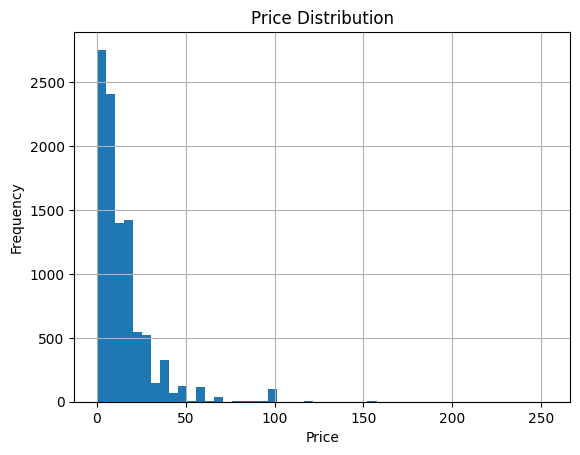

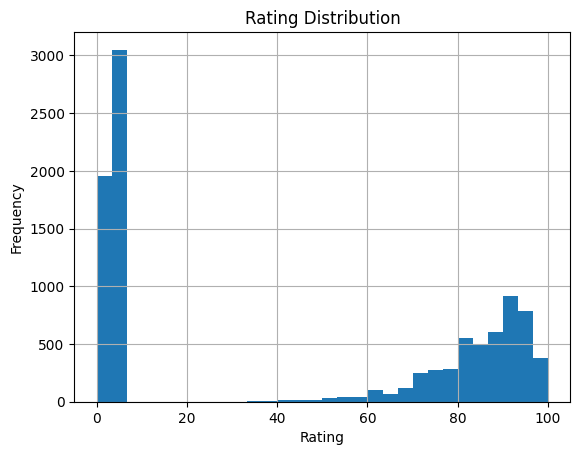

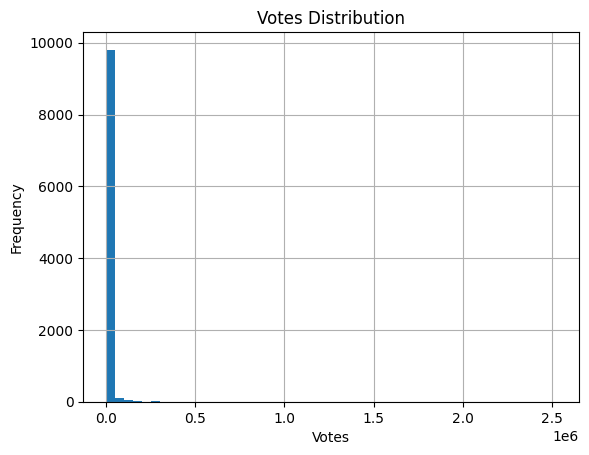


=== CORRELATION ANALYSIS ===
                   Price    Rating  Votes_In_Rates  Discount  Runtime_Pages  \
Price           1.000000  0.133224        0.028729 -0.282004      -0.095550   
Rating          0.133224  1.000000        0.150182 -0.015961      -0.833001   
Votes_In_Rates  0.028729  0.150182        1.000000 -0.013944      -0.128536   
Discount       -0.282004 -0.015961       -0.013944  1.000000       0.026541   
Runtime_Pages  -0.095550 -0.833001       -0.128536  0.026541       1.000000   
Game_Age       -0.159302 -0.255824        0.034314 -0.033646       0.319239   

                Game_Age  
Price          -0.159302  
Rating         -0.255824  
Votes_In_Rates  0.034314  
Discount       -0.033646  
Runtime_Pages   0.319239  
Game_Age        1.000000  

=== GROUP-BY ANALYSIS ===

Average Price by Source:
Source
Steam    17.449728
GOG      12.884296
Name: Price, dtype: float64

Average Rating by Source:
Source
Steam    84.77320
GOG       3.20466
Name: Rating, dtype: float64

A

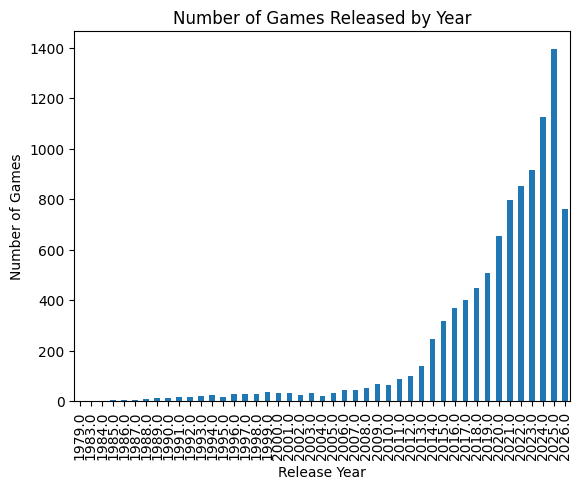

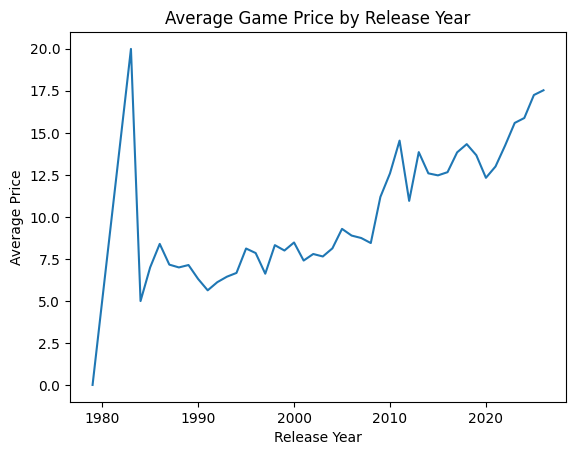


=== SOURCE COMPARISON ===


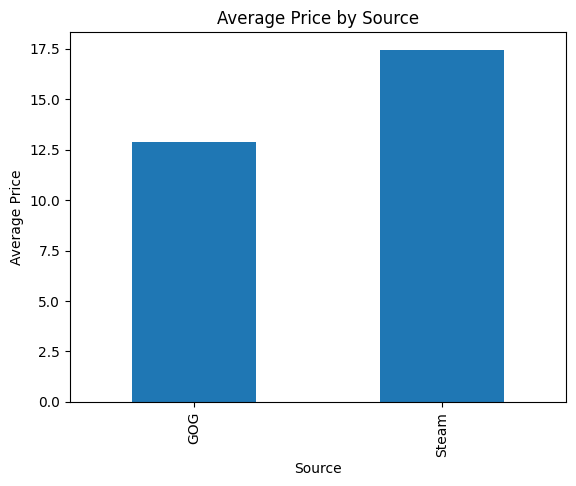

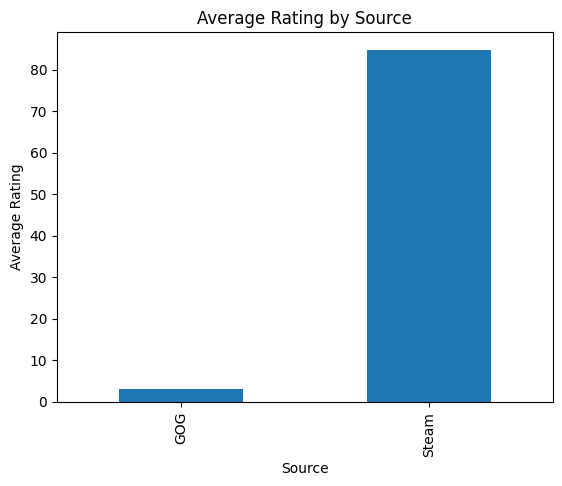


EDA complete.
Saved files:
eda_descriptive_statistics.csv
eda_custom_numeric_statistics.csv
eda_correlation_matrix.csv


In [8]:
# python eda_analysis.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE = "combined_cleaned_games_dataset.csv"

df = pd.read_csv(FILE, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
print(df.head())


# 1. MAKE SURE NUMERIC COLUMNS ARE NUMERIC

numeric_cols = [
    "Price",
    "Rating",
    "Votes_In_Rates",
    "Discount",
    "Runtime_Pages",
    "Release_Year",
    "Game_Age",
    "Price_To_Rating_Ratio",
    "Platform_Count"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# 2. DESCRIPTIVE STATISTICS

print("\n=== DESCRIPTIVE STATISTICS ===")

numeric_df = df.select_dtypes(include=["number"])

desc = numeric_df.describe()
print(desc)

stats = numeric_df.agg(["mean", "median", "std", "min", "max"])
print("\nCustom numeric stats:")
print(stats)


# 3. DISTRIBUTION ANALYSIS

print("\n=== DISTRIBUTION ANALYSIS ===")

plt.figure()
df["Price"].hist(bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df["Rating"].hist(bins=30)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df["Votes_In_Rates"].hist(bins=50)
plt.title("Votes Distribution")
plt.xlabel("Votes")
plt.ylabel("Frequency")
plt.show()


# 4. CORRELATION ANALYSIS

print("\n=== CORRELATION ANALYSIS ===")

corr_cols = ["Price", "Rating", "Votes_In_Rates", "Discount", "Runtime_Pages", "Game_Age"]
corr_cols = [col for col in corr_cols if col in df.columns]

corr = df[corr_cols].corr()
print(corr)


# 5. GROUP-BY ANALYSIS

print("\n=== GROUP-BY ANALYSIS ===")

print("\nAverage Price by Source:")
print(df.groupby("Source")["Price"].mean().sort_values(ascending=False))

print("\nAverage Rating by Source:")
print(df.groupby("Source")["Rating"].mean().sort_values(ascending=False))

print("\nAverage Price by Price Category:")
print(df.groupby("Price_Category")["Price"].mean())

print("\nAverage Rating by Platform:")
print(df.groupby("Platform")["Rating"].mean().sort_values(ascending=False).head(15))


# 6. TOP-N AND BOTTOM-N ANALYSIS

print("\n=== TOP / BOTTOM ANALYSIS ===")

print("\nTop 10 Most Expensive Games:")
print(df.sort_values("Price", ascending=False)[
    ["Title", "Source", "Price", "Rating", "Product_URL"]
].head(10))

print("\nBottom 10 Cheapest Games:")
print(df.sort_values("Price", ascending=True)[
    ["Title", "Source", "Price", "Rating", "Product_URL"]
].head(10))

print("\nTop 10 Highest Rated Games:")
print(df.sort_values("Rating", ascending=False)[
    ["Title", "Source", "Rating", "Votes_In_Rates", "Product_URL"]
].head(10))

print("\nTop 10 Most Voted Games:")
print(df.sort_values("Votes_In_Rates", ascending=False)[
    ["Title", "Source", "Votes_In_Rates", "Rating", "Product_URL"]
].head(10))


# 7. HYPOTHESIS TESTING

print("\n=== HYPOTHESIS TESTING ===")

print("\nH1: Discounted games are cheaper")
h1 = df.groupby("Is_Discounted")["Price"].mean()
print(h1)

print("\nH2: Higher-rated games have more votes")
h2 = df[["Rating", "Votes_In_Rates"]].corr()
print(h2)

print("\nH3: Newer games are more expensive")
h3 = df.groupby("Release_Year")["Price"].mean().dropna()
print(h3.tail(20))


# 8. TIME-BASED ANALYSIS

print("\n=== TIME-BASED ANALYSIS ===")

year_counts = df["Release_Year"].value_counts().sort_index()

plt.figure()
year_counts.plot(kind="bar")
plt.title("Number of Games Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Games")
plt.show()

year_price = df.groupby("Release_Year")["Price"].mean()

plt.figure()
year_price.plot(kind="line")
plt.title("Average Game Price by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Price")
plt.show()


# 9. SOURCE COMPARISON VISUALS

print("\n=== SOURCE COMPARISON ===")

plt.figure()
df.groupby("Source")["Price"].mean().plot(kind="bar")
plt.title("Average Price by Source")
plt.xlabel("Source")
plt.ylabel("Average Price")
plt.show()

plt.figure()
df.groupby("Source")["Rating"].mean().plot(kind="bar")
plt.title("Average Rating by Source")
plt.xlabel("Source")
plt.ylabel("Average Rating")
plt.show()


# 10. SAVE EDA OUTPUT TABLES

desc.to_csv("eda_descriptive_statistics.csv", encoding="utf-8-sig")
stats.to_csv("eda_custom_numeric_statistics.csv", encoding="utf-8-sig")
corr.to_csv("eda_correlation_matrix.csv", encoding="utf-8-sig")

print("\nEDA complete.")
print("Saved files:")
print("eda_descriptive_statistics.csv")
print("eda_custom_numeric_statistics.csv")
print("eda_correlation_matrix.csv")

Dataset shape: (10000, 27)
       APP_ID                                              Title  \
0  1841631965      Offworld Trading Company - Market Corrections   
1  2071181157                                        1000Xresist   
2  1750687415  1428: Shadows Over Silesia - Tourney At The Be...   
3  1280902753          The Excavation Of Hob'S Barrow - Art Book   
4  2050180334              1428: Shadows Over Silesia Soundtrack   

                                Genre  Rating  Votes_In_Rates Released_Date  \
0        Simulation, Sci-fi, Strategy     0.0             9.0    2019-02-27   
1        Adventure, Puzzle, Narrative     4.3            49.0    2024-05-08   
2          Action, Adventure, Fantasy     4.8             1.0    2024-11-10   
3  Adventure, Point-and-click, Puzzle     0.0             9.0    2022-09-27   
4          Action, Adventure, Fantasy     0.0             9.0    2022-10-03   

   Discount  Price             Platform  \
0       0.0   3.99         Windows, Mac   
1  

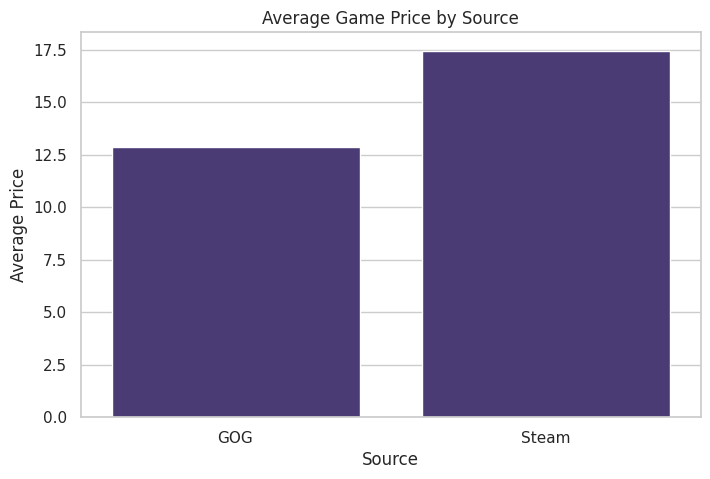

Caption: This chart compares average game prices between Steam and GOG.


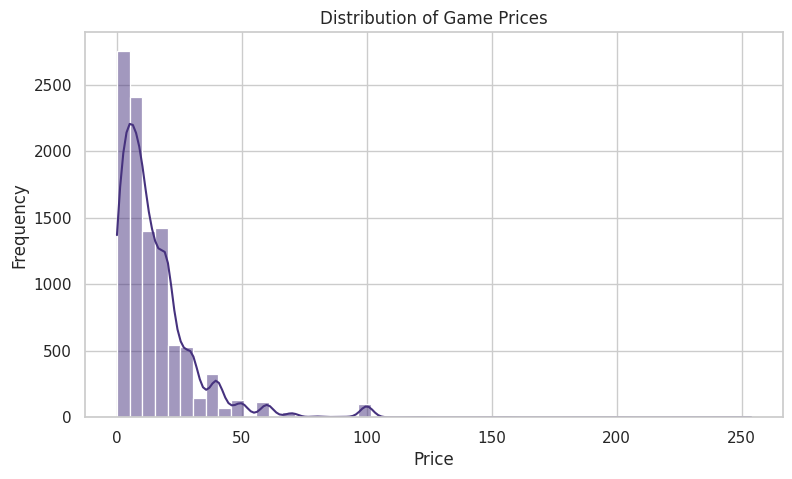

Caption: Game prices are right-skewed, with many cheap games and fewer expensive titles.


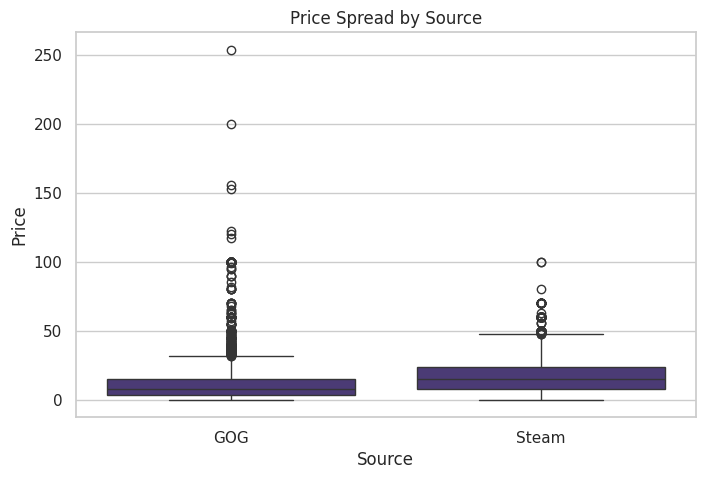

Caption: This box plot shows median price, spread, and outliers for each source.


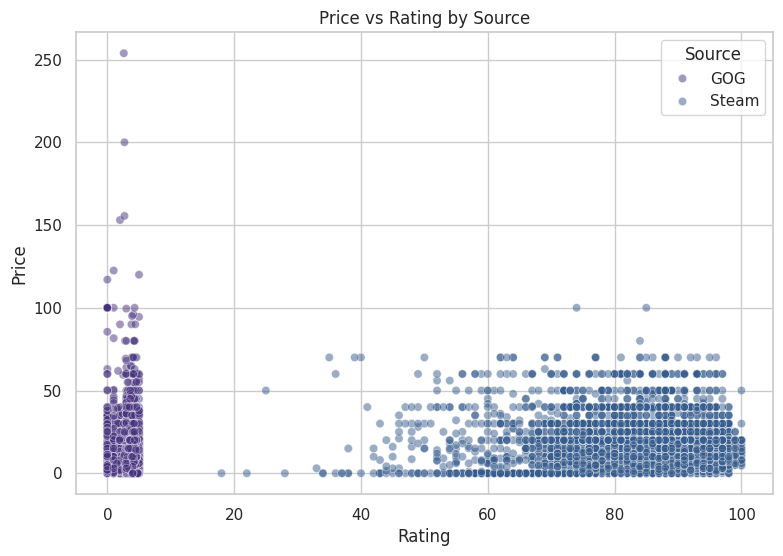

Caption: This scatter plot checks whether higher-rated games are more expensive.


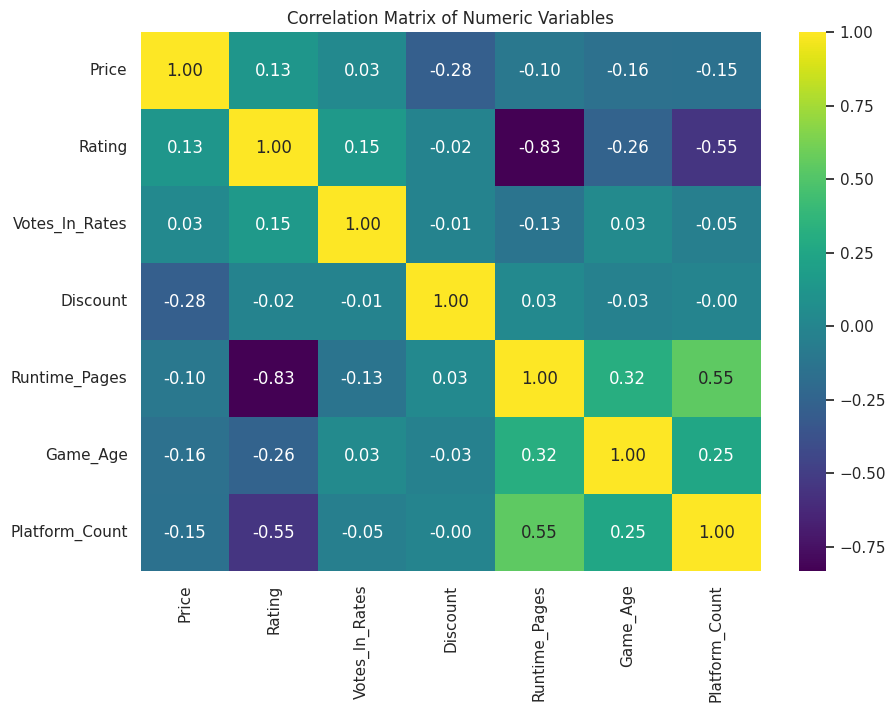

Caption: The heatmap shows linear relationships between numeric variables.


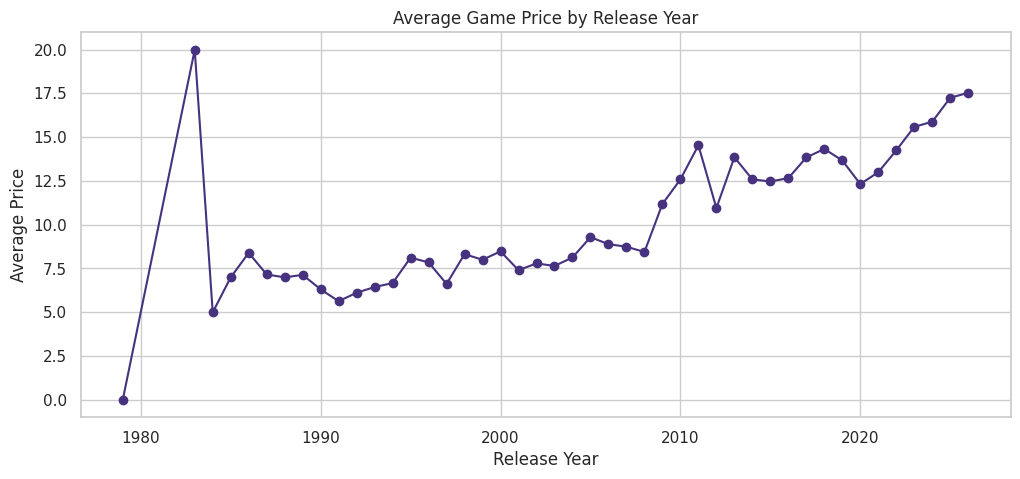

Caption: This line chart shows how average game prices changed over time.


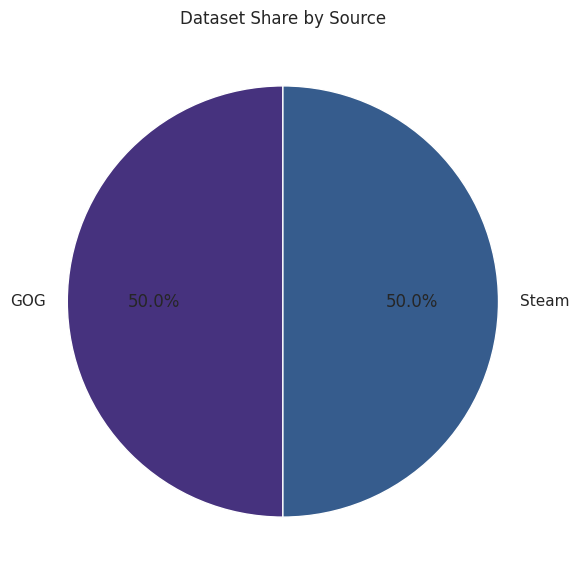

Caption: This pie chart shows the proportion of Steam and GOG records.


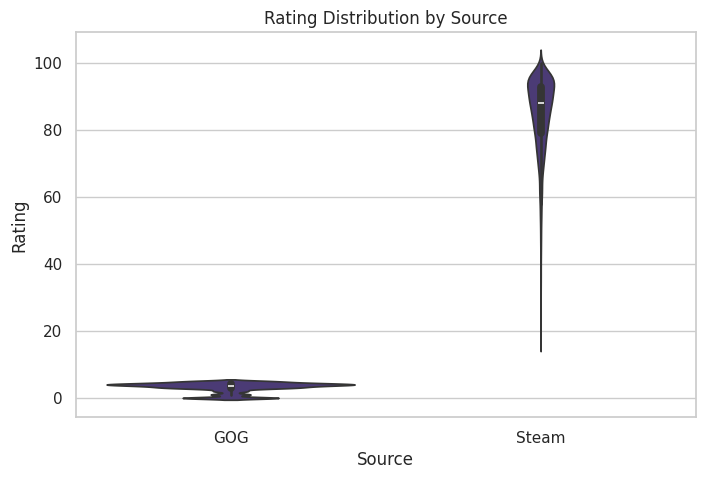

Caption: The violin plot shows rating density for each source.


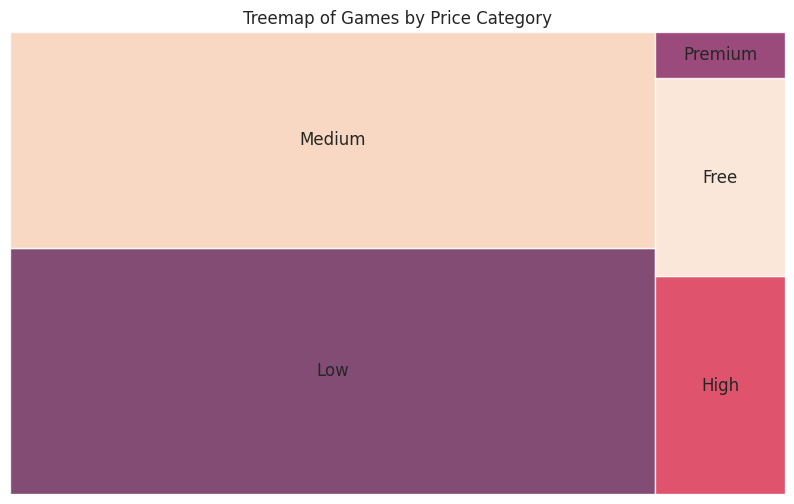

Caption: The treemap shows how games are distributed across price categories.


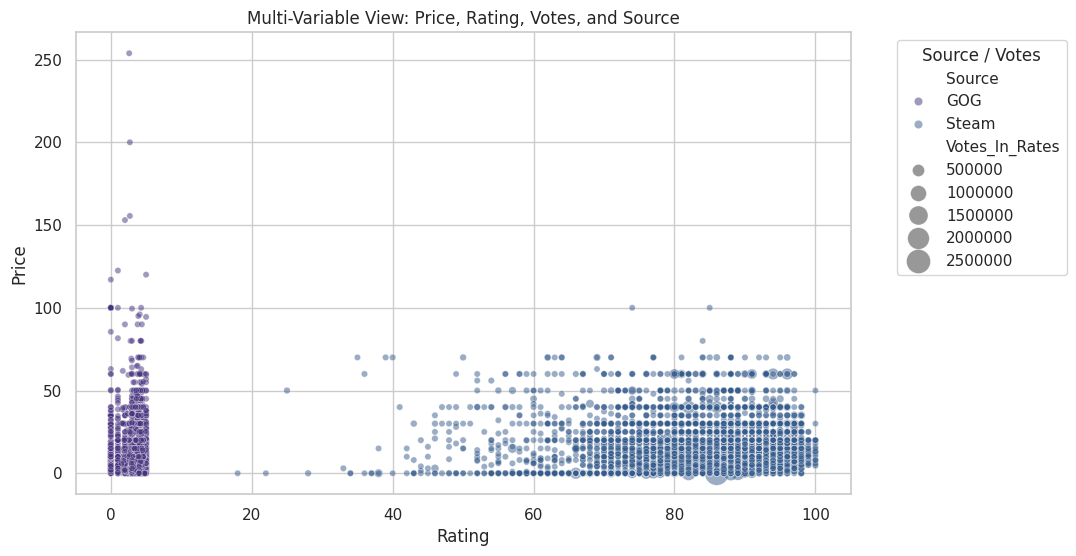

Caption: This chart uses color for source and point size for vote count.


Caption: This interactive scatter plot allows inspection of individual games.


Caption: This chart compares average prices across categories and sources.


Caption: This chart shows release trends over time by source.


Caption: This interactive box plot highlights price outliers by source.


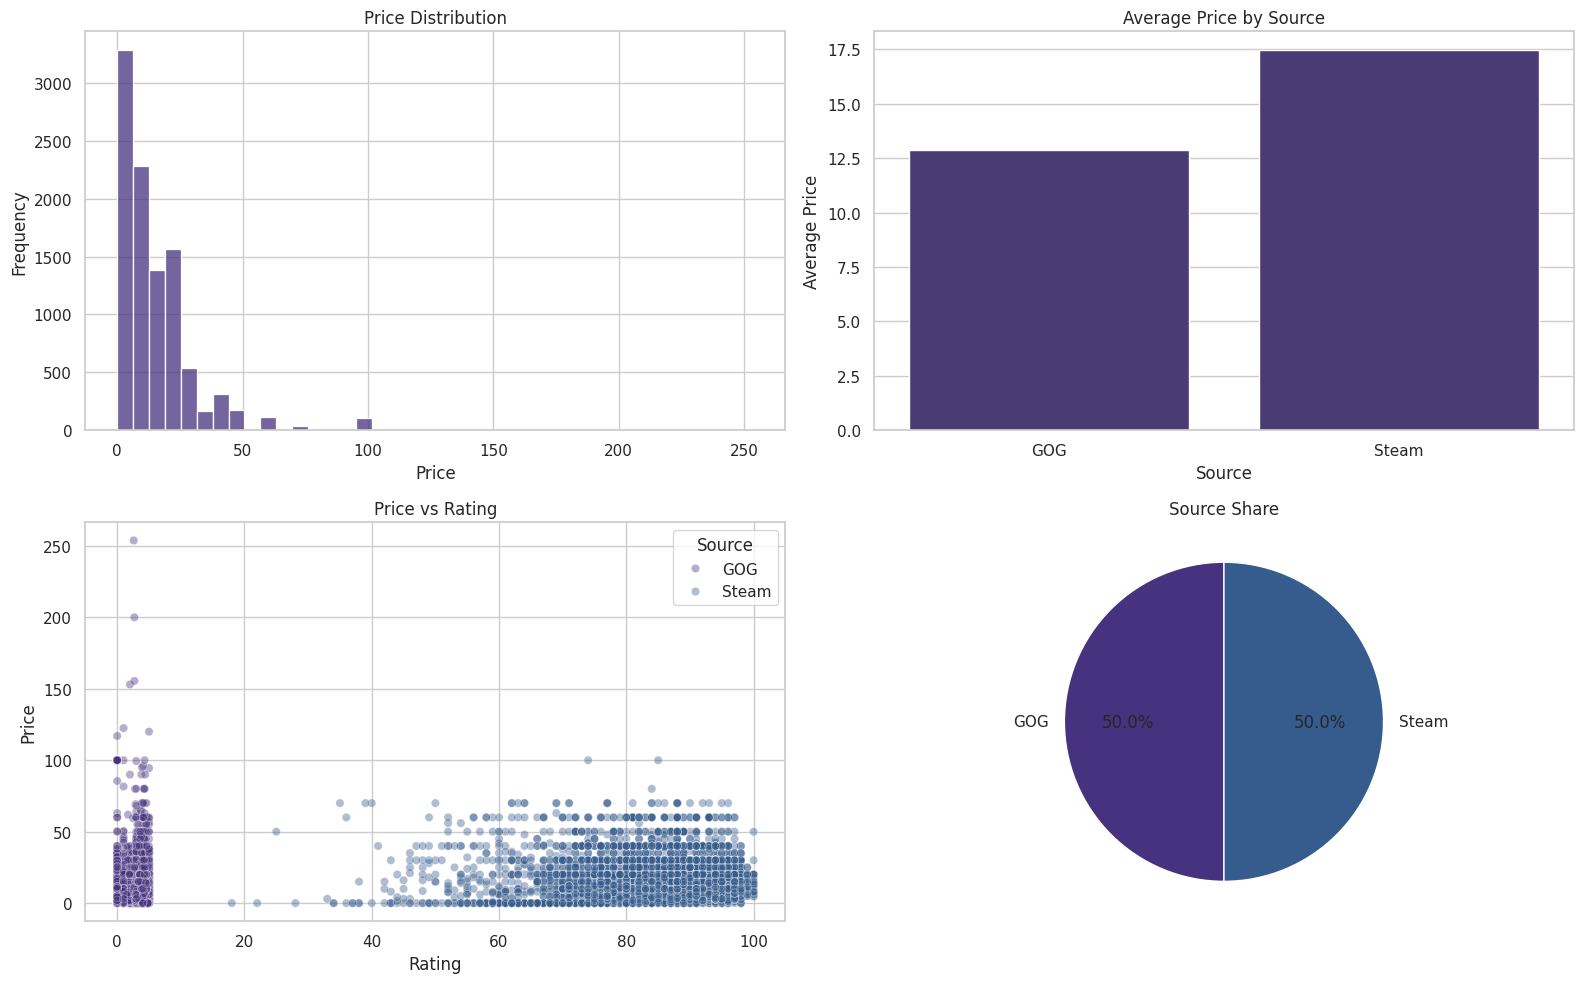

Caption: This dashboard combines key charts: price distribution, source comparison, price-rating relationship, and source composition.
Visualization phase complete.
Saved summary tables:
viz_avg_price_by_source.csv
viz_avg_rating_by_source.csv
viz_correlation_matrix.csv


In [10]:
# python visualization.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import squarify

FILE = "combined_cleaned_games_dataset.csv"

df = pd.read_csv(FILE, encoding="utf-8-sig")

sns.set_theme(style="whitegrid", palette="viridis")

numeric_cols = [
    "Price", "Rating", "Votes_In_Rates", "Discount",
    "Runtime_Pages", "Release_Year", "Game_Age",
    "Price_To_Rating_Ratio", "Platform_Count"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["Source"] = df["Source"].fillna("Unknown")
df["Platform"] = df["Platform"].fillna("Unknown")
df["Genre"] = df["Genre"].fillna("Unknown")
df["Price_Category"] = df["Price_Category"].fillna("Unknown")

print("Dataset shape:", df.shape)
print(df.head())


# 2. BAR CHART: AVERAGE PRICE BY SOURCE

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Source", y="Price", errorbar=None)
plt.title("Average Game Price by Source")
plt.xlabel("Source")
plt.ylabel("Average Price")
plt.show()

print("Caption: This chart compares average game prices between Steam and GOG.")


# 3. HISTOGRAM: PRICE DISTRIBUTION

plt.figure(figsize=(9, 5))
sns.histplot(df["Price"], bins=50, kde=True)
plt.title("Distribution of Game Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print("Caption: Game prices are right-skewed, with many cheap games and fewer expensive titles.")


# 4. BOX PLOT: PRICE BY SOURCE

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Source", y="Price")
plt.title("Price Spread by Source")
plt.xlabel("Source")
plt.ylabel("Price")
plt.show()

print("Caption: This box plot shows median price, spread, and outliers for each source.")


# 5. SCATTER PLOT: PRICE VS RATING

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Rating", y="Price", hue="Source", alpha=0.5)
plt.title("Price vs Rating by Source")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.legend(title="Source")
plt.show()

print("Caption: This scatter plot checks whether higher-rated games are more expensive.")


# 6. HEATMAP: CORRELATION MATRIX

corr_cols = [
    "Price", "Rating", "Votes_In_Rates", "Discount",
    "Runtime_Pages", "Game_Age", "Platform_Count"
]

corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

print("Caption: The heatmap shows linear relationships between numeric variables.")


# 7. LINE CHART: AVERAGE PRICE BY RELEASE YEAR

year_price = df.groupby("Release_Year")["Price"].mean().dropna()

plt.figure(figsize=(12, 5))
year_price.plot(kind="line", marker="o")
plt.title("Average Game Price by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Price")
plt.show()

print("Caption: This line chart shows how average game prices changed over time.")


# 8. PIE CHART: DATASET SHARE BY SOURCE

source_counts = df["Source"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(source_counts, labels=source_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Dataset Share by Source")
plt.show()

print("Caption: This pie chart shows the proportion of Steam and GOG records.")


# 9. VIOLIN PLOT: RATING DISTRIBUTION BY SOURCE

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Source", y="Rating")
plt.title("Rating Distribution by Source")
plt.xlabel("Source")
plt.ylabel("Rating")
plt.show()

print("Caption: The violin plot shows rating density for each source.")


# 10. TREEMAP: GAME COUNT BY PRICE CATEGORY

price_counts = df["Price_Category"].value_counts().reset_index()
price_counts.columns = ["Price_Category", "Count"]

plt.figure(figsize=(10, 6))
squarify.plot(
    sizes=price_counts["Count"],
    label=price_counts["Price_Category"],
    alpha=0.8
)
plt.title("Treemap of Games by Price Category")
plt.axis("off")
plt.show()

print("Caption: The treemap shows how games are distributed across price categories.")


# 11. MULTI-VARIABLE SCATTER: PRICE, RATING, VOTES, SOURCE

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rating",
    y="Price",
    size="Votes_In_Rates",
    hue="Source",
    alpha=0.5,
    sizes=(20, 300)
)
plt.title("Multi-Variable View: Price, Rating, Votes, and Source")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.legend(title="Source / Votes", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

print("Caption: This chart uses color for source and point size for vote count.")


# 12. INTERACTIVE PLOTLY SCATTER

fig = px.scatter(
    df,
    x="Rating",
    y="Price",
    color="Source",
    size="Votes_In_Rates",
    hover_data=["Title", "Platform", "Released_Date"],
    title="Interactive Scatter: Price vs Rating"
)

fig.update_layout(
    xaxis_title="Rating",
    yaxis_title="Price",
    legend_title="Source"
)

fig.show()

print("Caption: This interactive scatter plot allows inspection of individual games.")


# 13. INTERACTIVE PLOTLY BAR

grouped = df.groupby(["Source", "Price_Category"], as_index=False)["Price"].mean()

fig = px.bar(
    grouped,
    x="Price_Category",
    y="Price",
    color="Source",
    barmode="group",
    title="Interactive Bar Chart: Average Price by Category and Source"
)

fig.update_layout(
    xaxis_title="Price Category",
    yaxis_title="Average Price",
    legend_title="Source"
)

fig.show()

print("Caption: This chart compares average prices across categories and sources.")


# 14. INTERACTIVE PLOTLY LINE

year_source = (
    df.groupby(["Release_Year", "Source"])
    .size()
    .reset_index(name="Game_Count")
    .dropna()
)

fig = px.line(
    year_source,
    x="Release_Year",
    y="Game_Count",
    color="Source",
    markers=True,
    title="Interactive Line Chart: Game Releases Over Time"
)

fig.update_layout(
    xaxis_title="Release Year",
    yaxis_title="Number of Games",
    legend_title="Source"
)

fig.show()

print("Caption: This chart shows release trends over time by source.")


# 15. INTERACTIVE BOXPLOT

fig = px.box(
    df,
    x="Source",
    y="Price",
    color="Source",
    points="outliers",
    title="Interactive Box Plot: Price Outliers by Source"
)

fig.update_layout(
    xaxis_title="Source",
    yaxis_title="Price",
    legend_title="Source"
)

fig.show()

print("Caption: This interactive box plot highlights price outliers by source.")


# 16. DASHBOARD-STYLE FIGURE

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df["Price"], bins=40, ax=axes[0, 0])
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Frequency")

sns.barplot(data=df, x="Source", y="Price", errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title("Average Price by Source")
axes[0, 1].set_xlabel("Source")
axes[0, 1].set_ylabel("Average Price")

sns.scatterplot(data=df, x="Rating", y="Price", hue="Source", alpha=0.4, ax=axes[1, 0])
axes[1, 0].set_title("Price vs Rating")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Price")

source_counts = df["Source"].value_counts()
axes[1, 1].pie(source_counts, labels=source_counts.index, autopct="%1.1f%%", startangle=90)
axes[1, 1].set_title("Source Share")

plt.tight_layout()
plt.show()

print("Caption: This dashboard combines key charts: price distribution, source comparison, price-rating relationship, and source composition.")


# 17. SAVE OPTIONAL VISUALIZATION TABLES

df.groupby("Source")["Price"].mean().to_csv("viz_avg_price_by_source.csv", encoding="utf-8-sig")
df.groupby("Source")["Rating"].mean().to_csv("viz_avg_rating_by_source.csv", encoding="utf-8-sig")
df[corr_cols].corr().to_csv("viz_correlation_matrix.csv", encoding="utf-8-sig")

print("Visualization phase complete.")
print("Saved summary tables:")
print("viz_avg_price_by_source.csv")
print("viz_avg_rating_by_source.csv")
print("viz_correlation_matrix.csv")

In [11]:
readme_text = """# 🎮 Game Market Analysis (Steam + GOG)

## 📌 Project Overview

This project analyzes video game data collected from two platforms:

- Steam
- GOG (Good Old Games)

The objective is to explore:
- pricing behavior of games
- user ratings and popularity
- impact of discounts
- differences between platforms
- trends in game releases over time

The project follows a complete data analysis pipeline:

1. Web Scraping (Data Collection)
2. Data Cleaning & Transformation
3. Exploratory Data Analysis (EDA)
4. Data Visualization

The final dataset contains approximately 10,000 records.

---

## ⚙️ Dependencies

Install all required libraries:

pip install pandas numpy requests beautifulsoup4 matplotlib seaborn plotly squarify lxml

---

## 🚀 How to Run the Code

Step 1 — Run Scrapers:
python gog_scraper.py
python steam_scraper.py

Step 2 — Clean Data:
python gog_cleaning.py
python steam_cleaning.py

Step 3 — Combine Data (Python):
python combining two csv

Step 4 — Run EDA:
python eda_analysis.py

Step 5 — Run Visualization:
python visualization.py

---

## 📊 Dataset Description

Each record includes:
APP_ID, Title, Genre, Rating, Votes_In_Rates, Released_Date, Discount, Price, Platform, Director_Author, Product_URL, Source

---

## 👨‍💻 Author

SDS 106 — Algorithms and Programming 2
Spring 2026
Dastan
Amirzhan
Aidyn
Aldyar
"""


with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

print("README.md created successfully!")

README.md created successfully!
